# IAD Pipeline
Anomaly detection pipeline using FiftyOne, Weights & Biases, and the IAD framework.

## 1. Environment Setup
Configure database URI and API keys.

In [1]:
import os
import sys
import warnings
import yaml
# Set BEFORE any fiftyone imports
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost"
os.environ["WANDB_API_KEY"] = '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'

sys.path.append("src")

# Now safe to import
import wandb
import logging
from pathlib import Path
from src.manager import AnomalyDetectionManager as ADM
from src.manager import DatasetSession as DS

wandb.login()

/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
wandb: Currently logged in as: daniel-pommer (daniel-pommer-technische-hochschule-n-rnberg-georg-simon-ohm) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 2. Configuration
Set your run parameters here before executing the pipeline.

In [2]:
from src.userConfigs import Product


logger              = logging.getLogger("logger")

# productName         = "bottle"
# datasetName         = "MVTecADShortPred"

# datasetDir          = Path("../datasets/")
# configDir           = Path("../configs/")
# outputPath          = Path("../results/")
# productConfigPath   = Path(f"Products/{productName}.yaml")
# productConfigPath=Path(configDir/productConfigPath)

train               = True
evaluate            = True
datasetDir          = Path("datasets/")
configDir           = Path("configs/")
outputPath          = Path("results/")
datasetName         = "MVTecADShortPred"
productName         = "cable"
productPath         = Path(f"Products/{productName}.yaml")
productConfigPath   = Path(configDir/productPath)
logger              = logging.getLogger("logger")
split               = ("pred",)


product: Product
manager, product = ADM.loadProduct(productConfigPath=productConfigPath, outputPath=outputPath, configDir=configDir)
datasetSession = DS.loadDatasetFromDisk(datasetDir/datasetName, datasetName=datasetName, overwrite=True, merge=False, split=split)
# datasetSession = DS.loadDatasetFromConfig(product.datasetConfig, overwrite=True, merge=False, split=("pred",))


datasetSession.select_category(productName)
manager.adjustPaths(datasetName=datasetName, category=productName, adjustCheckpoints=False) # We want to use the checkpoints of the training dataset not the new predictions dataset (does not have checkpoints)
print(f"Output path: {manager.outputDir}")
print(f"Checkpoint path: {manager.ckptDir}")

Product: Product(name='cable', logFileName='general.log', modelConfig=ModelConfig(name='Padim', config=PadimConfig(backbone='resnet18', pre_trained=True, pre_processor=PreProcessor(), post_processor=AOIPostProcessor(
  (_image_threshold_metric): F1AdaptiveThreshold()
  (_pixel_threshold_metric): F1AdaptiveThreshold()
  (_image_min_max_metric): MinMax()
  (_pixel_min_max_metric): MinMax()
), evaluator=Evaluator(
  (val_metrics): ModuleList(
    (0): AUROC()
  )
  (test_metrics): ModuleList(
    (0): AUROC()
    (1): F1Score()
    (2): AUPR()
  )
), visualizer=True, layers=['layer1', 'layer2', 'layer3'], n_features=100), preProcessorPath=None, postProcessorPath=PosixPath('/Users/dapo/Documents/Code/IAD/configs/Engine/PostProcessor.yaml'), evaluatorPath=PosixPath('/Users/dapo/Documents/Code/IAD/configs/Engine/Evaluator.yaml')), modelName='Padim', modelConfigPath=PosixPath('/Users/dapo/Documents/Code/IAD/configs/Models/padim.yaml'), modelWeightsPath=PosixPath('/Users/dapo/Documents/Code/IA

/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'pre_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['pre_processor'])`.
/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'post_processor' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['post_processor'])`.
/Users/dapo/Documents/Code/IAD/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'evaluator' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['evaluator'])`.


INFO: Loading pretrained weights from Hugging Face hub (timm/resnet18.a1_in1k)
INFO: [timm/resnet18.a1_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO: Missing keys (fc.weight, fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.
INFO: Successfully loaded model Padim: Padim(
  (pre_processor): PreProcessor()
  (post_processor): AOIPostProcessor(
    (_image_threshold_metric): F1AdaptiveThreshold()
    (_pixel_threshold_metric): F1AdaptiveThreshold()
    (_image_min_max_metric): MinMax()
    (_pixel_min_max_metric): MinMax()
  )
  (evaluator): Evaluator(
    (val_metrics): ModuleList(
      (0): AUROC()
    )
    (test_metrics): ModuleList(
      (0): AUROC()
      (1): F1Score()
      (2): AUPR()
    )
  )
  (model): PadimModel(
    (feature_extractor): TimmFeatureExtractor(
      (feature_extractor): FeatureListNet(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), 

ERROR: Dataset name 'MVTecADShortPred-cable' is not available


ERROR: Dataset name 'MVTecADShortPred-cable' is not available
INFO: Deleting MVTecADShortPred-cable from database and reloading.
INFO: Set outputPath to results/MVTecADShortPred/Padim/tiled
INFO: Set ckptDir to results/MVTecADShort/Padim/tiled/checkpoints
Output path: results/MVTecADShortPred/Padim/tiled
Checkpoint path: results/MVTecADShort/Padim/tiled/checkpoints


## 3. Inspect Dataset

In [ ]:
datasetSession.launchSession()

## 4. Prediction

In [3]:
# if manager.ckptPath is not None:
    # if not manager.isTilingSetup:
    #     # manager.loadCheckpoint(manager.ckptPath, f"{manager.modelName}")
    # if manager.isTilingSetup:
    #     manager.setupTiling(configDir / "Tiling" / "TiledEnsemblePred.yaml")
print(product.inferencerConfig)
# if product.inferencerConfig is not None:
assert manager.modelConfig is not None
assert product.inferencerConfig is not None
manager.inference(
    trainingDir=product.modelTrainingDir,
    datasetSession=datasetSession,
    datamoduleConfig=product.datamoduleConfig,
    modelConfig=manager.modelConfig,
    inferencerConfig=product.inferencerConfig,
                #   resultsDir=manager.outputDir,
    tiling=manager.isTilingSetup,
    tilingPipelineConfig=product.tilingPipelineConfig)
                    #   ckptPath=manager.ckptDir,
                    #   trainingDir=productDescription["model"]["trainingDir"])
# print(manager.FO_Dataset)


TrainerConfig(accelerator='mps', strategy='auto', devices='auto', num_nodes=1, precision=None, logger=None, callbacks=None, fast_dev_run=False, max_epochs=1, min_epochs=None, max_steps=-1, min_steps=None, max_time=None, limit_train_batches=None, limit_val_batches=None, limit_test_batches=None, limit_predict_batches=None, overfit_batches=0.0, val_check_interval=None, check_val_every_n_epoch=1, num_sanity_val_steps=None, log_every_n_steps=None, enable_checkpointing=None, enable_progress_bar=None, enable_model_summary=None, accumulate_grad_batches=1, gradient_clip_val=None, gradient_clip_algorithm=None, deterministic=None, benchmark=None, inference_mode=True, use_distributed_sampler=True, profiler=None, detect_anomaly=False, barebones=False, plugins=None, sync_batchnorm=False, reload_dataloaders_every_n_epochs=0, default_root_dir=None)
INFO: Dataset used for training: <anomalib.data.predict.PredictDataset object at 0x33350ccd0>
INFO: No normal test images found. Sampling from training set

            might be empty or devoid of either normal or anomalous images.


            might be empty or devoid of either normal or anomalous images.
INFO: Dataset used for training: Name:        MVTecADShortPred-cable
Media type:  image
Num samples: 20
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    split:            fiftyone.core.fields.StringField
    label_index:      fiftyone.core.fields.IntField
    anomalyType:      fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)
    category:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)
    mask_path:        fiftyone.core.fields.S

Predict: 0it [00:00, ?it/s]

INFO: Tiled ensemble predicting started using Using ckpt_pathtest data.
INFO: Initializing Padim model.
INFO: Loading pretrained weights from Hugging Face hub (timm/resnet18.a1_in1k)


...

INFO: Job Visualize completed successfully.
INFO: Running job 51Visualize



51Visualize: 0it [00:00, ?it/s]

INFO: Starting visualisation for Fiftyone.


51 Visualisation: 100%|██████████| 20/20 [00:00<00:00, 77.19it/s]
51Visualize: 1it [00:00,  3.28it/s]

INFO: Job 51Visualize completed successfully.



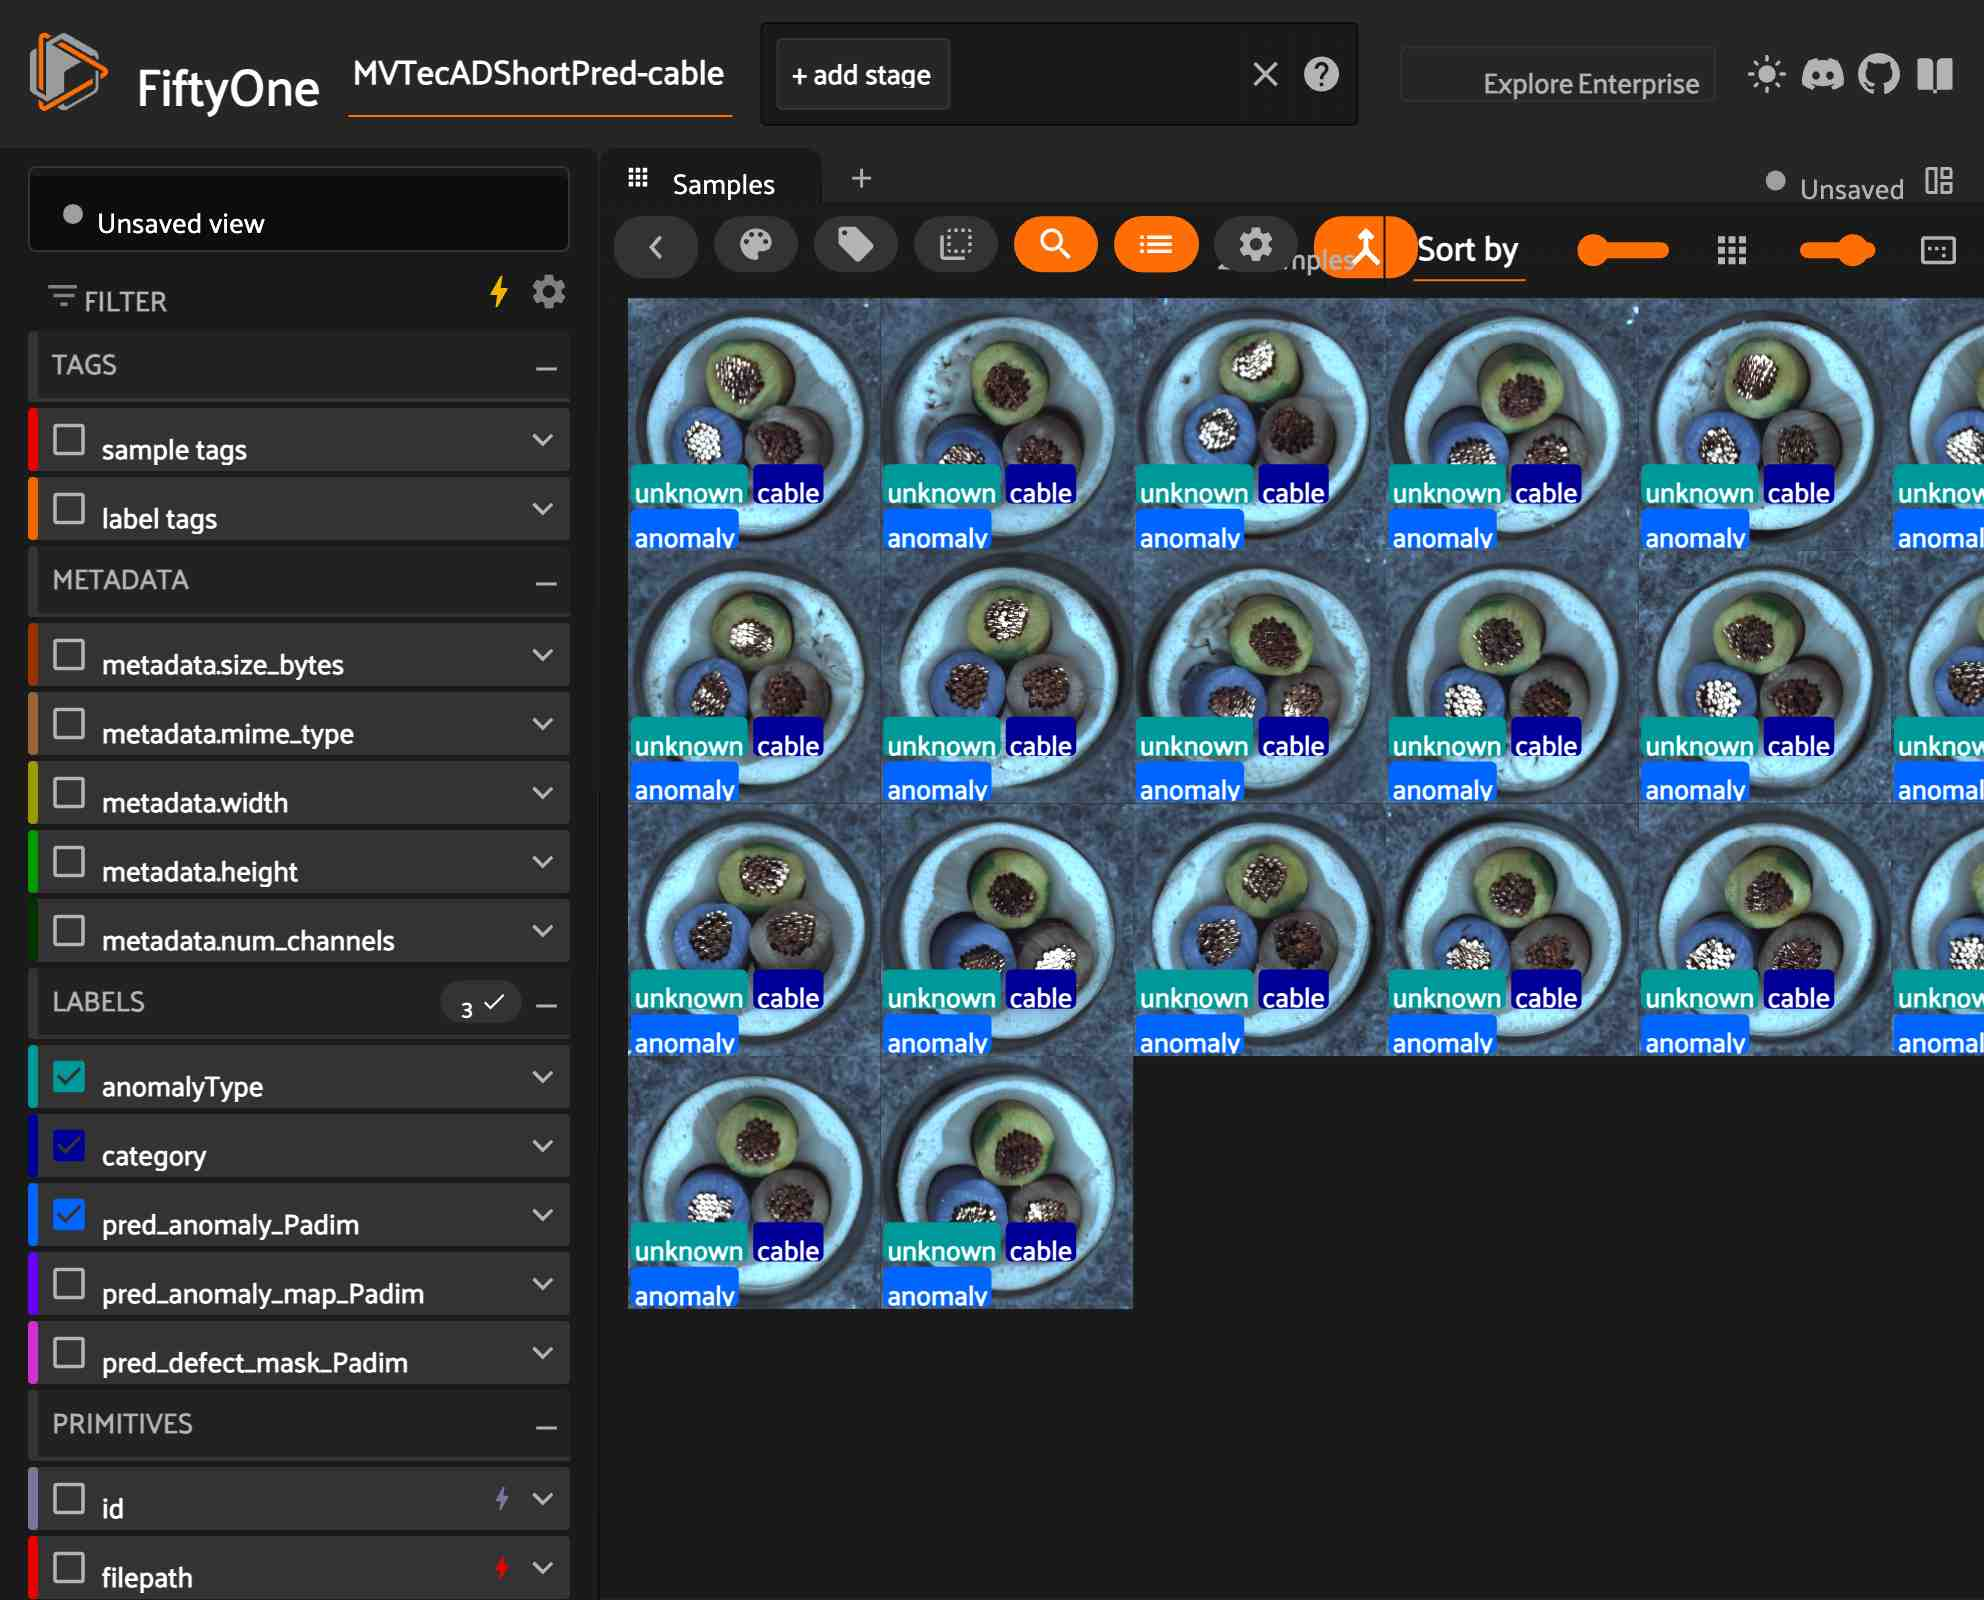

INFO: Session: localhost:5151


Dataset:          MVTecADShortPred-cable
Media type:       image
Num samples:      20
Selected samples: 0
Selected labels:  0
Session URL:      http://localhost:5151/

In [ ]:
datasetSession.launchSession()
